# FINAL CONSOLIDATED NOTEBOOK - ISCEV 2022 COMPLIANT ERG PIPELINE

**1- Configuration**

In [40]:
# ============================================================================
# CELL 1: ERG PIPELINE CONFIGURATION (ISCEV 2022 Compliant)
# Single source of truth - Version 1.0.0
# ============================================================================

import numpy as np
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
from datetime import datetime

@dataclass
class ERGConfig:
    """Master configuration for ISCEV 2022-compliant ERG processing pipeline"""

    # ========================================================================
    # ISCEV 2022 MANDATED PARAMETERS (Page 7, Col 2)
    # ========================================================================
    ISCEV_HIGHPASS_HZ: float = 0.3          # ≤0.3 Hz (Page 7, Col 2, Para 3)
    ISCEV_LOWPASS_HZ: float = 300.0         # ≥300 Hz (Page 7, Col 2, Para 3)
    ISCEV_MIN_SAMPLING_RATE_HZ: float = 1000.0   # ≥1 kHz (Page 7, Col 2, Para 2)
    ISCEV_MIN_PRESTIMULUS_MS: float = 20.0       # ≥20 ms (Page 7, Col 2, Para 5)
    ISCEV_MIN_RECORDING_MS: float = 300.0        # ≥300 ms (Page 7, Col 2, Para 5)
    ISCEV_OP_BAND_LOW_HZ: float = 75.0           # 75 Hz minimum (Page 7, Col 2, Para 4)
    ISCEV_FLASH_MAX_DURATION_MS: float = 5.0     # <5 ms (Page 4, Col 2, Para 2)

    # ========================================================================
    # FILTER PARAMETERS (Clinical Standard, not ISCEV-mandated)
    # ========================================================================
    BUTTERWORTH_ORDER: int = 4              # 4th-order (clinical standard)
    MEDIAN_KERNEL_MS: float = 5.0           # 5 ms for spike removal
    NOTCH_QUALITY_FACTOR: float = 30.0      # Q=30 (~1.67 Hz bandwidth)
    NOTCH_DEFAULT_STATE: bool = False       # OFF by default per ISCEV 2022

    # ========================================================================
    # ELECTRODE-SPECIFIC SNR THRESHOLDS (Chapter 2 Clinical Best Practice)
    # Not ISCEV-mandated - ISCEV provides no numerical SNR thresholds
    # ========================================================================
    ELECTRODE_SNR_THRESHOLDS: Dict[str, Dict[str, float]] = field(default_factory=lambda: {
        'contact_lens': {'pass': 8.0, 'warning_min': 4.0, 'fail_below': 4.0},
        'gold_foil': {'pass': 6.0, 'warning_min': 3.0, 'fail_below': 3.0},
        'dtl_fiber': {'pass': 4.0, 'warning_min': 2.5, 'fail_below': 2.5},
        'skin': {'pass': 3.0, 'warning_min': 1.5, 'fail_below': 1.5}
    })

    # ========================================================================
    # MAINS INTERFERENCE DETECTION (Audit only - NOT auto-apply)
    # ========================================================================
    MAINS_CANDIDATE_FREQS_HZ: List[float] = field(default_factory=lambda: [50.0, 60.0])
    MAINS_DETECTION_THRESHOLD_DB: float = 6.0   # Peak must exceed noise floor by 6 dB
    MAINS_DETECTION_BANDWIDTH_HZ: float = 2.0   # ±2 Hz around candidate

    # ========================================================================
    # OP BAND DETECTION
    # ========================================================================
    OP_BAND_SNR_THRESHOLD_DB: float = 3.0       # Minimum SNR to declare OP available
    OP_BAND_HIGH_HZ: float = 300.0              # Upper bound for OP band
    NOISE_BAND_LOW_HZ: float = 400.0            # For estimating noise floor
    NOISE_BAND_HIGH_HZ: float = 500.0           # For estimating noise floor

    # ========================================================================
    # QUALITY GRADING SCORES
    # ========================================================================
    QUALITY_SCORES: Dict[str, int] = field(default_factory=lambda: {
        'op_excellent': 3,      # OP SNR ≥10 dB
        'op_good': 2,           # OP available but SNR <10 dB
        'bandwidth_full': 2,    # ≥250 Hz
        'bandwidth_limited': 1, # 150-250 Hz
        'no_spikes': 2,         # spike_count = 0
        'minor_spikes': 1,      # spike_count ≤5
        'no_mains': 1           # No mains detected
    })

    # ========================================================================
    # QUALITY GRADE THRESHOLDS
    # ========================================================================
    QUALITY_GRADE_THRESHOLDS: Dict[str, int] = field(default_factory=lambda: {
        'A': 7,  # Score ≥7 = Excellent
        'B': 5,  # Score ≥5 = Good
        'C': 3   # Score ≥3 = Acceptable
    })

    # ========================================================================
    # AGE GROUP REFERENCE HANDLING (Committee Suggestion #3)
    # ========================================================================
    AGE_GROUPS: List[str] = field(default_factory=lambda: [
        '0-12mo', '1-5y', '6-12y', '13-17y', '18-80y', '80+y', 'unknown'
    ])
    DEFAULT_AGE_GROUP: str = '18-80y'

    # ========================================================================
    # PRE-STIMULUS BASELINE HANDLING (Committee Suggestion #1)
    # ========================================================================
    PRESTIMULUS_STATUS_THRESHOLDS_MS: Dict[str, float] = field(default_factory=lambda: {
        'adequate': 20.0,      # ≥20 ms = ISCEV compliant
        'partial_min': 10.0,   # 10-19 ms = partial warning
        'insufficient_min': 0.0 # <10 ms = insufficient
    })

    # ========================================================================
    # PIPELINE METADATA
    # ========================================================================
    PIPELINE_VERSION: str = "1.0.0"
    PIPELINE_NAME: str = "ISCEV 2022-Compliant ERG Processing Pipeline"

    def get_electrode_snr_status(self, electrode_type: str, snr_db: float) -> Tuple[str, str]:
        """Return (status, message) for given electrode type and SNR"""
        electrode_key = electrode_type.lower().replace(' ', '_')
        if electrode_key not in self.ELECTRODE_SNR_THRESHOLDS:
            return "UNKNOWN", f"Unknown electrode type: {electrode_type}"

        thresholds = self.ELECTRODE_SNR_THRESHOLDS[electrode_key]
        if snr_db >= thresholds['pass']:
            return "PASS", f"SNR {snr_db:.1f} dB ≥ {thresholds['pass']} dB threshold"
        elif snr_db >= thresholds['warning_min']:
            return "WARNING", f"SNR {snr_db:.1f} dB is below PASS threshold ({thresholds['pass']} dB)"
        else:
            return "FAIL", f"SNR {snr_db:.1f} dB is below WARNING threshold ({thresholds['warning_min']} dB)"

    def get_prestimulus_status(self, prestimulus_ms: float) -> Tuple[str, str]:
        """Return (status, message) for pre-stimulus baseline duration"""
        if prestimulus_ms >= self.PRESTIMULUS_STATUS_THRESHOLDS_MS['adequate']:
            return "ADEQUATE", f"Pre-stimulus baseline {prestimulus_ms:.1f} ms (≥20 ms ISCEV compliant)"
        elif prestimulus_ms >= self.PRESTIMULUS_STATUS_THRESHOLDS_MS['partial_min']:
            return "PARTIAL", f"Pre-stimulus baseline {prestimulus_ms:.1f} ms (<20 ms ISCEV minimum). Baseline estimate may be noisy."
        elif prestimulus_ms > 0:
            return "INSUFFICIENT", f"Pre-stimulus baseline {prestimulus_ms:.1f} ms (<10 ms). OP features may be unreliable."
        else:
            return "ABSENT", "No pre-stimulus baseline recorded. a-wave amplitude measurement may be inaccurate."

    def get_age_group_flag(self, age_group: str) -> Tuple[str, str]:
        """Return (reference_source, flag_message) for age group"""
        age_flags = {
            '0-12mo': ("pediatric", "WARNING: Pediatric reference ranges used; adult comparison not appropriate"),
            '1-5y': ("pediatric", "WARNING: Pediatric reference ranges used; adult comparison not appropriate"),
            '6-12y': ("pediatric_caution", "CAUTION: Partial maturation; interpret with caution"),
            '13-17y': ("near_adult", "Near-adult reference ranges applied"),
            '18-80y': ("adult", None),
            '80+y': ("elderly_caution", "CAUTION: Elderly reference ranges; age-related amplitude reduction expected"),
            'unknown': ("adult_fallback", "WARNING: Age not provided; adult reference ranges applied by default")
        }
        return age_flags.get(age_group, ("unknown", "WARNING: Unrecognized age group; adult ranges applied"))

    def to_dict(self) -> Dict:
        """Return configuration as dictionary for audit log"""
        return {
            'pipeline_version': self.PIPELINE_VERSION,
            'pipeline_name': self.PIPELINE_NAME,
            'iscev_highpass_hz': self.ISCEV_HIGHPASS_HZ,
            'iscev_lowpass_hz': self.ISCEV_LOWPASS_HZ,
            'iscev_min_sampling_rate_hz': self.ISCEV_MIN_SAMPLING_RATE_HZ,
            'iscev_min_prestimulus_ms': self.ISCEV_MIN_PRESTIMULUS_MS,
            'butterworth_order': self.BUTTERWORTH_ORDER,
            'median_kernel_ms': self.MEDIAN_KERNEL_MS,
            'notch_default_state': self.NOTCH_DEFAULT_STATE,
            'notch_q': self.NOTCH_QUALITY_FACTOR,
            'electrode_snr_thresholds': self.ELECTRODE_SNR_THRESHOLDS,
            'mains_detection_threshold_db': self.MAINS_DETECTION_THRESHOLD_DB,
            'op_band_snr_threshold_db': self.OP_BAND_SNR_THRESHOLD_DB,
            'quality_grade_thresholds': self.QUALITY_GRADE_THRESHOLDS
        }


# Instantiate master configuration
CONFIG = ERGConfig()

# Print confirmation
print("=" * 60)
print("ERG PIPELINE CONFIGURATION LOADED")
print("=" * 60)
print(f"Version: {CONFIG.PIPELINE_VERSION}")
print(f"ISCEV 2022 Compliance: High-pass {CONFIG.ISCEV_HIGHPASS_HZ} Hz, Low-pass {CONFIG.ISCEV_LOWPASS_HZ} Hz")
print(f"Notch filter default state: {'ON' if CONFIG.NOTCH_DEFAULT_STATE else 'OFF (ISCEV 2022 compliant)'}")
print(f"Electrode types supported: {list(CONFIG.ELECTRODE_SNR_THRESHOLDS.keys())}")
print(f"Age groups supported: {CONFIG.AGE_GROUPS}")
print("=" * 60)

ERG PIPELINE CONFIGURATION LOADED
Version: 1.0.0
ISCEV 2022 Compliance: High-pass 0.3 Hz, Low-pass 300.0 Hz
Notch filter default state: OFF (ISCEV 2022 compliant)
Electrode types supported: ['contact_lens', 'gold_foil', 'dtl_fiber', 'skin']
Age groups supported: ['0-12mo', '1-5y', '6-12y', '13-17y', '18-80y', '80+y', 'unknown']


**2- Utility Functions (Fixed Deprecation Warnings)**

In [41]:
# ============================================================================
# CELL 2: UTILITY FUNCTIONS (Fixed deprecation warnings - trapezoid not trapz)
# ============================================================================

import numpy as np
import pandas as pd
from scipy.signal import welch
from typing import Tuple, Dict, Any

def load_erg_csv(filepath: str) -> Tuple[np.ndarray, np.ndarray, float, Dict]:
    """Load ERG CSV file in standardized format (Time_ms, Amplitude_uV)"""
    df = pd.read_csv(filepath)

    time_col = None
    amp_col = None

    for col in df.columns:
        col_lower = col.lower()
        if 'time' in col_lower or 'ms' in col_lower:
            time_col = col
        if 'amplitude' in col_lower or 'uv' in col_lower or 'μv' in col_lower:
            amp_col = col

    if time_col is None or amp_col is None:
        raise ValueError(f"Cannot find time and amplitude columns. Found: {df.columns.tolist()}")

    time_ms = df[time_col].values
    signal_uv = df[amp_col].values

    dt_ms = np.median(np.diff(time_ms))
    fs_hz = 1000.0 / dt_ms

    metadata = {
        'filename': filepath,
        'n_samples': len(signal_uv),
        'duration_ms': time_ms[-1] - time_ms[0],
        'fs_hz': fs_hz,
        'time_col': time_col,
        'amp_col': amp_col
    }

    return time_ms, signal_uv, fs_hz, metadata


def compute_kernel_samples(fs_hz: float, kernel_ms: float = 5.0) -> int:
    """Convert kernel duration (ms) to samples, ensuring odd number for median filter"""
    kernel = int(fs_hz * kernel_ms / 1000)
    if kernel % 2 == 0:
        kernel += 1
    return max(kernel, 3)


def validate_iscev_requirements(fs_hz: float, prestimulus_ms: float) -> Dict[str, Any]:
    """Validate ISCEV 2022 minimum requirements"""
    results = {
        'sampling_rate_ok': fs_hz >= CONFIG.ISCEV_MIN_SAMPLING_RATE_HZ,
        'sampling_rate_value': fs_hz,
        'sampling_rate_required': CONFIG.ISCEV_MIN_SAMPLING_RATE_HZ,
        'prestimulus_ok': prestimulus_ms >= CONFIG.ISCEV_MIN_PRESTIMULUS_MS,
        'prestimulus_value': prestimulus_ms,
        'prestimulus_required': CONFIG.ISCEV_MIN_PRESTIMULUS_MS,
        'overall_compliant': False
    }

    results['overall_compliant'] = results['sampling_rate_ok'] and results['prestimulus_ok']

    warnings_list = []
    if not results['sampling_rate_ok']:
        warnings_list.append(f"Sampling rate {fs_hz:.1f} Hz below ISCEV minimum {CONFIG.ISCEV_MIN_SAMPLING_RATE_HZ} Hz")
    if not results['prestimulus_ok']:
        warnings_list.append(f"Pre-stimulus baseline {prestimulus_ms:.1f} ms below ISCEV minimum {CONFIG.ISCEV_MIN_PRESTIMULUS_MS} ms")

    results['warnings'] = warnings_list
    return results


def calculate_snr(signal_uv: np.ndarray, fs_hz: float, noise_band_hz: Tuple[float, float] = (400, 500)) -> float:
    """Calculate signal-to-noise ratio using signal power in 0-300 Hz vs noise band"""
    freqs, psd = welch(signal_uv, fs=fs_hz, nperseg=min(1024, len(signal_uv)))

    signal_mask = freqs <= 300
    signal_power = np.trapezoid(psd[signal_mask], freqs[signal_mask])

    noise_mask = (freqs >= noise_band_hz[0]) & (freqs <= noise_band_hz[1])
    if np.any(noise_mask):
        noise_power = np.trapezoid(psd[noise_mask], freqs[noise_mask])
    else:
        noise_power = signal_power * 0.01

    snr_db = 10 * np.log10((signal_power + 1e-30) / (noise_power + 1e-30))
    return snr_db


print("\n" + "=" * 60)
print("UTILITY FUNCTIONS LOADED (No deprecation warnings)")
print("=" * 60)
test_kernel = compute_kernel_samples(1000, 5.0)
print(f"Kernel calculation test: 1000 Hz, 5 ms → {test_kernel} samples")
print("=" * 60)


UTILITY FUNCTIONS LOADED (No deprecation warnings)
Kernel calculation test: 1000 Hz, 5 ms → 5 samples


**3- Stage 1 - Pre-Processing Audit**

In [42]:
# ============================================================================
# CELL 3: STAGE 1 - PRE-PROCESSING AUDIT (Fixed np.trapezoid)
# ============================================================================

from scipy.signal import welch, find_peaks
from scipy.stats import median_abs_deviation
from scipy import stats
import warnings

class ERGAudit:
    """Pre-Processing Audit for ERG Signals - No filtering applied"""

    def __init__(self, config: ERGConfig = None):
        self.config = config or CONFIG

    def run_full_audit(self, signal_uv: np.ndarray, fs_hz: float,
                       electrode_type: str = 'contact_lens',
                       prestimulus_samples: int = 0) -> Dict[str, Any]:

        signal_clean = np.nan_to_num(signal_uv)
        prestimulus_ms = prestimulus_samples * 1000.0 / fs_hz if prestimulus_samples > 0 else 0
        prestimulus_status, prestimulus_msg = self.config.get_prestimulus_status(prestimulus_ms)

        iscev_compliance = validate_iscev_requirements(fs_hz, prestimulus_ms)
        snr_db = calculate_snr(signal_clean, fs_hz)
        snr_status, snr_msg = self.config.get_electrode_snr_status(electrode_type, snr_db)

        bandwidth_result = self._analyze_bandwidth(signal_clean, fs_hz)
        op_result = self._analyze_oscillatory_potentials(signal_clean, fs_hz)
        mains_result = self._analyze_mains_interference(signal_clean, fs_hz)
        artifact_result = self._analyze_artifacts(signal_clean, fs_hz)
        quality_grade, grade_score, grade_desc = self._assign_quality_grade(
            op_result, bandwidth_result, artifact_result, mains_result, snr_status)
        age_flags = self.config.get_age_group_flag(self.config.DEFAULT_AGE_GROUP)

        return {
            'prestimulus': {'status': prestimulus_status, 'message': prestimulus_msg, 'ms': prestimulus_ms},
            'iscev_compliance': iscev_compliance,
            'snr': {'db': round(snr_db, 1), 'electrode_type': electrode_type, 'status': snr_status, 'message': snr_msg},
            'bandwidth': bandwidth_result,
            'oscillatory_potentials': op_result,
            'mains_interference': mains_result,
            'artifacts': artifact_result,
            'quality': {'grade': quality_grade, 'score': grade_score, 'description': grade_desc},
            'age_handling': {'reference_source': age_flags[0], 'flag': age_flags[1]}
        }

    def _analyze_bandwidth(self, signal: np.ndarray, fs_hz: float) -> Dict[str, Any]:
        freqs, psd = welch(signal, fs=fs_hz, nperseg=min(1024, len(signal)))
        psd_db = 10 * np.log10(psd + 1e-30)

        noise_mask = (freqs >= 400) & (freqs <= 500)
        noise_floor_db = np.mean(psd_db[noise_mask]) if np.any(noise_mask) else np.mean(psd_db[freqs >= 300])

        threshold_db = noise_floor_db + 6
        high_mask = (freqs >= 100) & (freqs <= fs_hz/2)
        above_threshold = psd_db[high_mask] > threshold_db

        if np.any(above_threshold):
            freq_above = freqs[high_mask][above_threshold]
            estimated_high_hz = freq_above[-1] if len(freq_above) > 0 else 300.0
            hardware_cutoff_hz = estimated_high_hz
            confidence = "HIGH" if estimated_high_hz >= 250 else "MEDIUM"
        else:
            estimated_high_hz = 300.0
            hardware_cutoff_hz = None
            confidence = "LOW"

        return {'estimated_high_hz': round(estimated_high_hz, 0), 'hardware_cutoff_hz': hardware_cutoff_hz, 'confidence': confidence, 'noise_floor_db': round(noise_floor_db, 1)}

    def _analyze_oscillatory_potentials(self, signal: np.ndarray, fs_hz: float) -> Dict[str, Any]:
        freqs, psd = welch(signal, fs=fs_hz, nperseg=min(1024, len(signal)))

        op_mask = (freqs >= self.config.ISCEV_OP_BAND_LOW_HZ) & (freqs <= self.config.OP_BAND_HIGH_HZ)
        op_band_energy = np.trapezoid(psd[op_mask], freqs[op_mask])

        noise_mask = (freqs >= self.config.NOISE_BAND_LOW_HZ) & (freqs <= self.config.NOISE_BAND_HIGH_HZ)
        if np.any(noise_mask):
            noise_band_energy = np.trapezoid(psd[noise_mask], freqs[noise_mask])
            snr_db = 10 * np.log10((op_band_energy + 1e-30) / (noise_band_energy + 1e-30))
        else:
            noise_band_energy = 0
            snr_db = -np.inf

        if snr_db >= self.config.OP_BAND_SNR_THRESHOLD_DB:
            available = True
            quality = "excellent" if snr_db >= 10 else "good"
            reason = f"OP band SNR = {snr_db:.1f} dB (≥ threshold)"
        else:
            available = False
            quality = "absent"
            reason = f"OP band SNR = {snr_db:.1f} dB (< {self.config.OP_BAND_SNR_THRESHOLD_DB} dB threshold)"

        return {'available': available, 'quality': quality, 'snr_db': round(snr_db, 1), 'reason': reason}

    def _analyze_mains_interference(self, signal: np.ndarray, fs_hz: float) -> Dict[str, Any]:
        freqs, psd = welch(signal, fs=fs_hz, nperseg=min(1024, len(signal)))
        psd_db = 10 * np.log10(psd + 1e-30)

        noise_mask = np.ones_like(freqs, dtype=bool)
        for candidate in self.config.MAINS_CANDIDATE_FREQS_HZ:
            noise_mask &= ~((freqs >= candidate - 5) & (freqs <= candidate + 5))
        noise_floor_db = np.mean(psd_db[noise_mask]) if np.any(noise_mask) else -80

        results = {'detected_hz': None, 'excess_db': 0, 'confidence': 'NONE'}

        for candidate in self.config.MAINS_CANDIDATE_FREQS_HZ:
            idx = np.argmin(np.abs(freqs - candidate))
            peak_db = psd_db[idx]
            excess_db = peak_db - noise_floor_db

            if excess_db > self.config.MAINS_DETECTION_THRESHOLD_DB and excess_db > results['excess_db']:
                results['detected_hz'] = candidate
                results['excess_db'] = round(excess_db, 1)
                results['confidence'] = 'HIGH' if excess_db >= 10 else 'MEDIUM'

        results['recommended_action'] = 'SKIP (ISCEV 2022 compliant)' if results['detected_hz'] is None else f'DETECTED: {results["detected_hz"]} Hz - Notch filter NOT recommended'
        return results

    def _analyze_artifacts(self, signal: np.ndarray, fs_hz: float) -> Dict[str, Any]:
        mad = median_abs_deviation(signal)
        threshold = 5 * mad
        spikes = np.where(np.abs(signal - np.median(signal)) > threshold)[0]

        if len(spikes) > 0:
            spike_groups = []
            current_group = [spikes[0]]
            for i in range(1, len(spikes)):
                if spikes[i] - spikes[i-1] <= 5:
                    current_group.append(spikes[i])
                else:
                    spike_groups.append(current_group)
                    current_group = [spikes[i]]
            spike_groups.append(current_group)
            spike_count = len(spike_groups)
            max_spike_uv = float(np.max(np.abs(signal[spikes]))) if len(spikes) > 0 else 0
        else:
            spike_count = 0
            max_spike_uv = 0.0

        t = np.arange(len(signal)) / fs_hz * 1000
        slope, _, _, _, _ = stats.linregress(t, signal)
        drift_uv_per_ms = slope

        percentile_99 = np.percentile(signal, 99)
        percentile_1 = np.percentile(signal, 1)
        saturation = bool(np.any(signal >= percentile_99 * 0.99) or np.any(signal <= percentile_1 * 0.99))

        freqs, psd = welch(signal, fs=fs_hz, nperseg=min(1024, len(signal)))
        emg_mask = (freqs >= 100) & (freqs <= 500)
        op_mask = (freqs >= 75) & (freqs <= 300)

        if np.any(emg_mask) and np.any(op_mask):
            emg_energy = np.sum(psd[emg_mask])
            op_energy = np.sum(psd[op_mask])
            emg_ratio = emg_energy / (op_energy + 1e-30)
            emg_level = "LOW" if emg_ratio < 0.5 else ("MODERATE" if emg_ratio < 1.5 else "HIGH")
        else:
            emg_level = "UNKNOWN"

        return {'spike_count': spike_count, 'max_spike_uv': round(max_spike_uv, 2), 'drift_uv_per_ms': round(drift_uv_per_ms, 4), 'saturation': saturation, 'emg_level': emg_level}

    def _assign_quality_grade(self, op_result, bandwidth_result, artifact_result, mains_result, snr_status):
        score = 0
        if op_result['available'] and op_result['quality'] == 'excellent':
            score += 3
        elif op_result['available']:
            score += 2
        if bandwidth_result['estimated_high_hz'] >= 250:
            score += 2
        elif bandwidth_result['estimated_high_hz'] >= 150:
            score += 1
        if artifact_result['spike_count'] == 0 and not artifact_result['saturation']:
            score += 2
        elif artifact_result['spike_count'] <= 5 and not artifact_result['saturation']:
            score += 1
        if snr_status == "PASS":
            score += 1
        if mains_result['detected_hz'] is None:
            score += 1

        if score >= 7:
            return "A", score, "Excellent - Full ISCEV bandwidth preserved, clean signal"
        elif score >= 5:
            return "B", score, "Good - Minor issues present, OP features likely usable"
        elif score >= 3:
            return "C", score, "Acceptable - OP features may be compromised"
        else:
            return "D", score, "Poor - Significant issues, OP features unavailable"


print("\n" + "=" * 60)
print("STAGE 1: PRE-PROCESSING AUDIT - READY")
print("=" * 60)
print("ERGAudit class instantiated. Ready to analyze signals.")
print("=" * 60)


STAGE 1: PRE-PROCESSING AUDIT - READY
ERGAudit class instantiated. Ready to analyze signals.


**4- Stage 2 - Conditional Filtering**

In [43]:
# ============================================================================
# CELL 4: STAGE 2 - CONDITIONAL FILTERING (ISCEV 2022 Compliant)
# ============================================================================

from scipy.signal import butter, sosfiltfilt, iirnotch, tf2sos, medfilt

class ERGFilter:
    """ISCEV 2022-Compliant ERG Filtering Pipeline"""

    def __init__(self, config: ERGConfig = None):
        self.config = config or CONFIG

    def design_bandpass(self, lowcut_hz: float, highcut_hz: float, fs_hz: float) -> np.ndarray:
        nyquist = fs_hz / 2.0
        if highcut_hz >= nyquist:
            raise ValueError(f"Low-pass cutoff {highcut_hz} Hz exceeds Nyquist ({nyquist} Hz)")
        low = lowcut_hz / nyquist
        high = highcut_hz / nyquist
        return butter(self.config.BUTTERWORTH_ORDER, [low, high], btype='bandpass', output='sos')

    def apply_bandpass(self, signal: np.ndarray, fs_hz: float, lowcut_hz: float = None, highcut_hz: float = None) -> np.ndarray:
        if lowcut_hz is None:
            lowcut_hz = self.config.ISCEV_HIGHPASS_HZ
        if highcut_hz is None:
            highcut_hz = self.config.ISCEV_LOWPASS_HZ
        sos = self.design_bandpass(lowcut_hz, highcut_hz, fs_hz)
        return sosfiltfilt(sos, signal)

    def apply_median(self, signal: np.ndarray, fs_hz: float) -> np.ndarray:
        kernel_samples = compute_kernel_samples(fs_hz, self.config.MEDIAN_KERNEL_MS)
        return medfilt(signal, kernel_size=kernel_samples)

    def design_notch(self, notch_hz: float, fs_hz: float) -> np.ndarray:
        b, a = iirnotch(notch_hz, self.config.NOTCH_QUALITY_FACTOR, fs=fs_hz)
        return tf2sos(b, a)

    def apply_notch(self, signal: np.ndarray, fs_hz: float, notch_hz: float) -> np.ndarray:
        sos = self.design_notch(notch_hz, fs_hz)
        return sosfiltfilt(sos, signal)

    def run_filter_pipeline(self, signal: np.ndarray, fs_hz: float,
                           apply_notch: bool = False, notch_hz: float = 50.0,
                           hardware_cutoff_hz: float = None,
                           user_confirmed_notch: bool = False) -> Tuple[np.ndarray, List[str]]:
        log = []
        sig = signal.copy()

        # Step 1: Median filter (always applied)
        sig_before = sig.copy()
        sig = self.apply_median(sig, fs_hz)
        spike_removed = np.sum(np.abs(sig_before - sig) > 5) > 0
        log.append(f"Median filter: kernel={self.config.MEDIAN_KERNEL_MS} ms, {compute_kernel_samples(fs_hz, self.config.MEDIAN_KERNEL_MS)} samples")
        if spike_removed:
            log.append("  - Spikes detected and removed")

        # Step 2: Notch filter (OFF by default - ISCEV 2022 compliance)
        if apply_notch and user_confirmed_notch:
            log.append(f"⚠️ NOTCH FILTER: User override at {notch_hz} Hz, Q={self.config.NOTCH_QUALITY_FACTOR}")
            sig = self.apply_notch(sig, fs_hz, notch_hz)
            log.append("   WARNING: Notch filters distort ERG waveform per ISCEV 2022")
        else:
            log.append(f"Notch filter: SKIPPED (ISCEV 2022 compliant - OFF by default)")

        # Step 3: Determine effective high-pass cutoff
        effective_high_hz = self.config.ISCEV_LOWPASS_HZ
        if hardware_cutoff_hz is not None and hardware_cutoff_hz < self.config.ISCEV_LOWPASS_HZ:
            effective_high_hz = hardware_cutoff_hz * 0.95
            log.append(f"Hardware cutoff detected: {hardware_cutoff_hz:.0f} Hz → effective: {effective_high_hz:.0f} Hz")

        # Step 4: Butterworth bandpass
        sig = self.apply_bandpass(sig, fs_hz, self.config.ISCEV_HIGHPASS_HZ, effective_high_hz)
        log.append(f"Butterworth bandpass: order={self.config.BUTTERWORTH_ORDER}, {self.config.ISCEV_HIGHPASS_HZ}-{effective_high_hz:.0f} Hz (zero-phase)")

        return sig, log

    def extract_ops(self, signal: np.ndarray, fs_hz: float) -> np.ndarray:
        sos = self.design_bandpass(self.config.ISCEV_OP_BAND_LOW_HZ, self.config.OP_BAND_HIGH_HZ, fs_hz)
        return sosfiltfilt(sos, signal)


print("\n" + "=" * 60)
print("STAGE 2: CONDITIONAL FILTERING - READY")
print("=" * 60)
print("Filter pipeline: Median → Notch (OFF by default) → Butterworth Bandpass")
print("ISCEV 2022: Notch filter OFF by default (Page 7, Col 2, Para 4)")
print("=" * 60)


STAGE 2: CONDITIONAL FILTERING - READY
Filter pipeline: Median → Notch (OFF by default) → Butterworth Bandpass
ISCEV 2022: Notch filter OFF by default (Page 7, Col 2, Para 4)


**5- Stage 3 - Feature Extraction**

In [44]:
# ============================================================================
# CELL 5: STAGE 3 - FEATURE EXTRACTION (with flash midpoint correction)
# ============================================================================

from scipy.signal import find_peaks

class ERGFeatureExtractor:
    """ISCEV 2022-Compliant Feature Extraction"""

    def __init__(self, config: ERGConfig = None):
        self.config = config or CONFIG

    def extract_awave_bwave(self, signal: np.ndarray, fs_hz: float,
                            flash_onset_sample: int = 0,
                            flash_duration_ms: float = 1.0) -> Dict[str, Any]:

        a_wave_window_ms = (10, 35)
        b_wave_window_ms = (30, 100)

        a_start = flash_onset_sample + int(a_wave_window_ms[0] * fs_hz / 1000)
        a_end = flash_onset_sample + int(a_wave_window_ms[1] * fs_hz / 1000)
        b_start = flash_onset_sample + int(b_wave_window_ms[0] * fs_hz / 1000)
        b_end = flash_onset_sample + int(b_wave_window_ms[1] * fs_hz / 1000)

        a_start = max(0, min(a_start, len(signal)-1))
        a_end = max(a_start+1, min(a_end, len(signal)))
        b_start = max(0, min(b_start, len(signal)-1))
        b_end = max(b_start+1, min(b_end, len(signal)))

        a_segment = signal[a_start:a_end]
        if len(a_segment) > 0:
            a_trough_idx_local = np.argmin(a_segment)
            a_trough_idx = a_start + a_trough_idx_local
            a_wave_amplitude = signal[a_trough_idx]
            a_wave_implicit_samples = a_trough_idx - flash_onset_sample
            a_wave_implicit_ms = a_wave_implicit_samples * 1000.0 / fs_hz
        else:
            a_wave_amplitude = np.nan
            a_wave_implicit_ms = np.nan

        b_segment = signal[b_start:b_end]
        if len(b_segment) > 0:
            b_peak_idx_local = np.argmax(b_segment)
            b_peak_idx = b_start + b_peak_idx_local
            b_wave_amplitude = signal[b_peak_idx] - a_wave_amplitude
            b_wave_implicit_samples = b_peak_idx - flash_onset_sample
            b_wave_implicit_ms = b_wave_implicit_samples * 1000.0 / fs_hz
        else:
            b_wave_amplitude = np.nan
            b_wave_implicit_ms = np.nan

        ba_ratio = b_wave_amplitude / abs(a_wave_amplitude) if a_wave_amplitude != 0 else np.nan

        correction_applied = False
        correction_ms = 0.0

        if flash_duration_ms >= self.config.ISCEV_FLASH_MAX_DURATION_MS:
            correction_ms = flash_duration_ms / 2.0
            a_wave_implicit_ms = a_wave_implicit_ms - correction_ms
            b_wave_implicit_ms = b_wave_implicit_ms - correction_ms
            correction_applied = True

        return {
            'a_wave_amplitude_uv': round(float(a_wave_amplitude), 1),
            'a_wave_implicit_time_ms': round(float(a_wave_implicit_ms), 1),
            'b_wave_amplitude_uv': round(float(b_wave_amplitude), 1),
            'b_wave_implicit_time_ms': round(float(b_wave_implicit_ms), 1),
            'ba_ratio': round(float(ba_ratio), 2),
            'flash_midpoint_correction_applied': correction_applied,
            'flash_midpoint_correction_ms': correction_ms
        }

    def extract_all_features(self, signal: np.ndarray, fs_hz: float,
                             protocol: str = 'DA 3',
                             flash_onset_sample: int = 0,
                             flash_duration_ms: float = 1.0,
                             op_signal: np.ndarray = None) -> Dict[str, Any]:

        features = {'protocol': protocol}

        if '30' not in protocol:
            awave_bwave = self.extract_awave_bwave(signal, fs_hz, flash_onset_sample, flash_duration_ms)
            features.update(awave_bwave)

        if op_signal is not None:
            features['op_extracted'] = True

        return features


print("\n" + "=" * 60)
print("STAGE 3: FEATURE EXTRACTION - READY")
print("=" * 60)
print("Features: a-wave amplitude, a-wave implicit time, b-wave amplitude,")
print("          b-wave implicit time, b/a ratio, flash midpoint correction")
print("=" * 60)


STAGE 3: FEATURE EXTRACTION - READY
Features: a-wave amplitude, a-wave implicit time, b-wave amplitude,
          b-wave implicit time, b/a ratio, flash midpoint correction


**6- Stage 4 - Compliance Report**

In [45]:
# ============================================================================
# CELL 6 (FIXED): STAGE 4 - COMPLIANCE REPORT WITH PROPER Z-SCORES
# Fixed: Electrode type handling
# ============================================================================

from datetime import datetime

class ERGReportGenerator:
    """Generates ISCEV 2022 Compliance Report with proper Z-score calculation"""

    def __init__(self, config: ERGConfig = None):
        self.config = config or CONFIG

        # Electrode-specific reference ranges for DA 3.0 protocol
        self.REFERENCE_RANGES = {
            'contact_lens': {
                'a_amp': (-85, 15),
                'a_imp': (18, 2.5),
                'b_amp': (280, 45),
                'b_imp': (52, 6),
            },
            'gold_foil': {
                'a_amp': (-75, 14),
                'a_imp': (18, 2.5),
                'b_amp': (260, 45),
                'b_imp': (52, 6),
            },
            'dtl_fiber': {
                'a_amp': (-60, 12),
                'a_imp': (18, 2.5),
                'b_amp': (200, 40),
                'b_imp': (52, 6),
            },
            'skin': {
                'a_amp': (-30, 8),
                'a_imp': (19, 3),
                'b_amp': (100, 25),
                'b_imp': (54, 7),
            }
        }

    def calculate_z_score(self, value, mean, sd):
        """Calculate Z-score for a given value"""
        if value is None or np.isnan(value):
            return 0.0
        if sd == 0:
            return 0.0
        return round((value - mean) / sd, 2)

    def compute_z_scores(self, features: Dict, electrode_type: str) -> Dict[str, float]:
        """Compute Z-scores for all extracted features"""
        # Handle case where electrode_type might be a dictionary or widget
        if isinstance(electrode_type, dict):
            electrode_type = electrode_type.get('value', 'gold_foil')
        elif not isinstance(electrode_type, str):
            electrode_type = str(electrode_type)

        # Get reference ranges, default to gold_foil if not found
        ref = self.REFERENCE_RANGES.get(electrode_type)
        if ref is None:
            ref = self.REFERENCE_RANGES['gold_foil']

        z_scores = {}

        if 'a_wave_amplitude_uv' in features and features['a_wave_amplitude_uv']:
            z_scores['a_wave_amplitude'] = self.calculate_z_score(
                abs(features['a_wave_amplitude_uv']), abs(ref['a_amp'][0]), ref['a_amp'][1])

        if 'a_wave_implicit_time_ms' in features and features['a_wave_implicit_time_ms']:
            z_scores['a_wave_implicit_time'] = self.calculate_z_score(
                features['a_wave_implicit_time_ms'], ref['a_imp'][0], ref['a_imp'][1])

        if 'b_wave_amplitude_uv' in features and features['b_wave_amplitude_uv']:
            z_scores['b_wave_amplitude'] = self.calculate_z_score(
                features['b_wave_amplitude_uv'], ref['b_amp'][0], ref['b_amp'][1])

        if 'b_wave_implicit_time_ms' in features and features['b_wave_implicit_time_ms']:
            z_scores['b_wave_implicit_time'] = self.calculate_z_score(
                features['b_wave_implicit_time_ms'], ref['b_imp'][0], ref['b_imp'][1])

        if 'ba_ratio' in features and features['ba_ratio']:
            z_scores['ba_ratio'] = self.calculate_z_score(features['ba_ratio'], 4.0, 0.8)

        return z_scores

    def generate_traffic_light(self, z_scores: Dict[str, float]) -> Dict[str, Any]:
        """Generate traffic light based on Z-scores"""
        if not z_scores:
            return {'signal': 'YELLOW', 'color': '🟡', 'message': 'Insufficient data', 'confidence': 0.5}

        max_abs_z = 0
        worst_param = None
        worst_value = 0

        for param, z in z_scores.items():
            if z is not None and abs(z) > max_abs_z:
                max_abs_z = abs(z)
                worst_param = param
                worst_value = z

        if max_abs_z <= 2.0:
            return {
                'signal': 'GREEN',
                'color': '🟢',
                'message': 'All ERG parameters within normal limits. No immediate action required.',
                'confidence': 0.95,
                'max_z_score': max_abs_z,
                'worst_parameter': worst_param,
                'worst_z_score': worst_value
            }
        elif max_abs_z <= 3.0:
            direction = "delay" if "implicit" in str(worst_param) and worst_value > 0 else "reduction"
            return {
                'signal': 'AMBER',
                'color': '🟡',
                'message': f'Borderline abnormality: {worst_param} {direction} (Z={max_abs_z:.1f}). Specialist review recommended.',
                'confidence': 0.85,
                'max_z_score': max_abs_z,
                'worst_parameter': worst_param,
                'worst_z_score': worst_value
            }
        else:
            direction = "delay" if "implicit" in str(worst_param) and worst_value > 0 else "reduction"
            return {
                'signal': 'RED',
                'color': '🔴',
                'message': f'Significant abnormality: {worst_param} {direction} (Z={max_abs_z:.1f}). Urgent review required.',
                'confidence': 0.90,
                'max_z_score': max_abs_z,
                'worst_parameter': worst_param,
                'worst_z_score': worst_value
            }

    def generate_full_report(self, features: Dict, audit_results: Dict,
                             electrode_type: str,
                             filtered_signal: np.ndarray,
                             time_ms: np.ndarray,
                             filter_log: List[str],
                             processing_time_ms: float) -> Dict[str, Any]:

        z_scores = self.compute_z_scores(features, electrode_type)
        traffic_light = self.generate_traffic_light(z_scores)

        key_findings = []
        for param, z in z_scores.items():
            if abs(z) > 1.5:
                param_name = param.replace('_', ' ').title()
                if z > 0:
                    key_findings.append(f"{param_name} increased/delayed (Z={z:+.1f})")
                else:
                    key_findings.append(f"{param_name} reduced (Z={z:+.1f})")

        # Ensure electrode_type is string for display
        if isinstance(electrode_type, dict):
            electrode_type = electrode_type.get('value', 'unknown')

        return {
            'layer_1_traffic_light': traffic_light,
            'layer_2_clinical_summary': {
                'traffic_signal': traffic_light['signal'],
                'quality_grade': audit_results.get('quality', {}).get('grade', 'unknown'),
                'key_findings': key_findings,
                'z_scores': z_scores,
                'recommended_action': traffic_light['message'],
                'disclaimer': "This ERG Traffic Signal is generated solely from electroretinographic signal analysis. It represents ERG findings only and must be interpreted in the context of the patient's full clinical picture."
            },
            'layer_4_technical_audit': {
                'report_id': f"ERG-{datetime.now().strftime('%Y%m%d-%H%M%S')}",
                'timestamp': datetime.now().isoformat(),
                'pipeline_version': self.config.PIPELINE_VERSION,
                'electrode_type': electrode_type,
                'z_scores': z_scores,
                'filter_log': filter_log
            }
        }


print("\n" + "=" * 60)
print("STAGE 4: COMPLIANCE REPORT - FIXED")
print("=" * 60)
print("Reference ranges loaded for: contact_lens, gold_foil, dtl_fiber, skin")
print("=" * 60)


STAGE 4: COMPLIANCE REPORT - FIXED
Reference ranges loaded for: contact_lens, gold_foil, dtl_fiber, skin


**7- Colab UI Integration (Full Pipeline)t**

In [46]:
# ============================================================================
# CELL 7: COLAB UI INTEGRATION - FULL PIPELINE EXECUTION
# ============================================================================

import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import files

print("=" * 60)
print("ERG PROCESSING PIPELINE - CLINICAL DECISION SUPPORT API")
print("ISCEV 2022 Compliant | Version 1.0.0")
print("=" * 60)

# File upload
upload_widget = widgets.FileUpload(accept='.csv', multiple=False, description='Upload ERG File', button_style='primary')

# Patient inputs
age_group_widget = widgets.Dropdown(options=['18-80y', '13-17y', '6-12y', '1-5y', '0-12mo', '80+y', 'unknown'], value='18-80y', description='Age Group:')
pupil_status_widget = widgets.RadioButtons(options=['Dilated (≥6mm)', 'Natural'], value='Dilated (≥6mm)', description='Pupil Status:')
pupil_diameter_widget = widgets.FloatSlider(value=6.0, min=0, max=10, step=0.5, description='Pupil Diameter (mm):')
electrode_widget = widgets.Dropdown(options=['contact_lens', 'gold_foil', 'dtl_fiber', 'skin'], value='contact_lens', description='Electrode Type:')
protocol_widget = widgets.ToggleButtons(options=['DA 0.01', 'DA 3', 'DA 10', 'LA 3', 'LA 30 Hz'], value='DA 3', description='Protocol:')
environment_widget = widgets.Dropdown(options=['Shielded lab', 'Clinic', 'Portable'], value='Shielded lab', description='Environment:')
flash_duration_widget = widgets.FloatText(value=1.0, description='Flash Duration (ms):')
op_extract_widget = widgets.Checkbox(value=False, description='Extract Oscillatory Potentials (75-300 Hz)')
notch_override_widget = widgets.Checkbox(value=False, description='⚠️ OVERRIDE: Apply Notch Filter (ISCEV advises against)')
notch_consent_widget = widgets.Checkbox(value=False, description='I confirm clinical justification for notch filter override')
run_button = widgets.Button(description='▶ RUN PIPELINE', button_style='success', layout=widgets.Layout(width='200px'))
output_area = widgets.Output()

# Layout
ui = widgets.VBox([
    upload_widget,
    widgets.HTML("<hr>"),
    widgets.HTML("<b>📋 PATIENT INFORMATION</b>"),
    age_group_widget,
    widgets.HBox([pupil_status_widget, pupil_diameter_widget]),
    electrode_widget,
    environment_widget,
    widgets.HTML("<hr>"),
    widgets.HTML("<b>⚡ PROTOCOL & RECORDING</b>"),
    protocol_widget,
    flash_duration_widget,
    op_extract_widget,
    widgets.HTML("<hr>"),
    widgets.HTML("<b>⚠️ ISCEV 2022 COMPLIANCE</b>"),
    widgets.HTML("<font color='red'>Notch filters are NOT recommended by ISCEV (Page 7, Col 2, Para 4)</font>"),
    notch_override_widget,
    notch_consent_widget,
    widgets.HTML("<hr>"),
    run_button,
    output_area
])

display(ui)

def run_pipeline(b):
    with output_area:
        clear_output()

        if not upload_widget.value:
            print("❌ Please upload an ERG CSV file first")
            return

        if notch_override_widget.value and not notch_consent_widget.value:
            print("❌ Notch filter override requires confirmation of clinical justification")
            return

        uploaded_file = list(upload_widget.value.values())[0]
        filename = uploaded_file['metadata']['name']
        content = uploaded_file['content']

        temp_path = f"/tmp/{filename}"
        with open(temp_path, 'wb') as f:
            f.write(content)

        print("=" * 60)
        print("PROCESSING ERG SIGNAL...")
        print("=" * 60)
        print(f"File: {filename}")
        print(f"Age Group: {age_group_widget.value}")
        print(f"Electrode: {electrode_widget.value}")
        print(f"Protocol: {protocol_widget.value}")
        print(f"Flash Duration: {flash_duration_widget.value} ms")
        print(f"Notch Filter: {'APPLIED (override)' if notch_override_widget.value else 'SKIPPED (ISCEV compliant)'}")
        print("-" * 60)

        try:
            time_ms, signal_uv, fs_hz, metadata = load_erg_csv(temp_path)
            print(f"✓ Signal loaded: {len(signal_uv)} samples @ {fs_hz:.0f} Hz")

            prestimulus_samples = int(0.020 * fs_hz)
            auditor = ERGAudit()
            audit_result = auditor.run_full_audit(signal_uv, fs_hz, electrode_widget.value, prestimulus_samples)

            print(f"✓ Audit complete: Grade {audit_result['quality']['grade']}")
            print(f"  OP Available: {audit_result['oscillatory_potentials']['available']}")
            print(f"  SNR: {audit_result['snr']['db']} dB ({audit_result['snr']['status']})")

            filter_obj = ERGFilter()
            hardware_cutoff = audit_result['bandwidth'].get('hardware_cutoff_hz')

            filtered_signal, filter_log = filter_obj.run_filter_pipeline(
                signal_uv, fs_hz,
                apply_notch=notch_override_widget.value,
                notch_hz=50.0,
                hardware_cutoff_hz=hardware_cutoff,
                user_confirmed_notch=notch_consent_widget.value
            )

            print(f"✓ Filtering complete")

            extractor = ERGFeatureExtractor()
            op_signal = None
            if op_extract_widget.value and audit_result['oscillatory_potentials']['available']:
                op_signal = filter_obj.extract_ops(filtered_signal, fs_hz)
                print(f"✓ OP signal extracted (75-300 Hz)")

            features = extractor.extract_all_features(
                filtered_signal, fs_hz, protocol_widget.value,
                flash_onset_sample=0, flash_duration_ms=flash_duration_widget.value,
                op_signal=op_signal
            )

            print(f"✓ Features extracted")
            if 'a_wave_amplitude_uv' in features:
                print(f"  a-wave: {features['a_wave_amplitude_uv']} µV @ {features['a_wave_implicit_time_ms']} ms")
                print(f"  b-wave: {features['b_wave_amplitude_uv']} µV @ {features['b_wave_implicit_time_ms']} ms")

            z_scores = {'a_wave_amplitude': 0.5, 'b_wave_amplitude': -0.3, 'b_wave_implicit_time': 0.8}

            # Generate full report with proper electrode type
            report_gen = ERGReportGenerator()

            # Get electrode type as string (handle widget value)
            electrode_value = electrode_widget.value
            if hasattr(electrode_value, 'value'):
                electrode_value = electrode_value.value

            full_report = report_gen.generate_full_report(
                features=features,
                audit_results=audit_result,
                electrode_type=electrode_value,
                filtered_signal=filtered_signal,
                time_ms=time_ms,
                filter_log=filter_log,
                processing_time_ms=250.0
            )

            print("-" * 60)
            print("\n" + "=" * 60)
            print("FINAL REPORT")
            print("=" * 60)

            tl = full_report['layer_1_traffic_light']
            print(f"\n{tl['color']} TRAFFIC LIGHT: {tl['signal']}")
            print(f"   {tl['message']}")
            print(f"   Confidence: {tl['confidence']:.0%}")
            print(f"\n📊 QUALITY GRADE: {audit_result['quality']['grade']}")
            print(f"   {audit_result['quality']['description']}")
            print(f"\n📋 RECOMMENDED ACTION: {full_report['layer_2_clinical_summary']['recommended_action']}")
            print("\n" + "=" * 60)
            print("✅ Pipeline execution complete")
            print("=" * 60)

        except Exception as e:
            print(f"❌ Error: {e}")
            import traceback
            traceback.print_exc()

run_button.on_click(run_pipeline)
print("\n✓ UI Ready - Please upload an ERG CSV file and click 'RUN PIPELINE'")

ERG PROCESSING PIPELINE - CLINICAL DECISION SUPPORT API
ISCEV 2022 Compliant | Version 1.0.0



✓ UI Ready - Please upload an ERG CSV file and click 'RUN PIPELINE'


**8-Synthetic ERG Generator for 7 Disease Classes**

SYNTHETIC ERG GENERATOR FOR 7 DISEASE CLASSES
ISCEV 2022 Compliant Waveforms


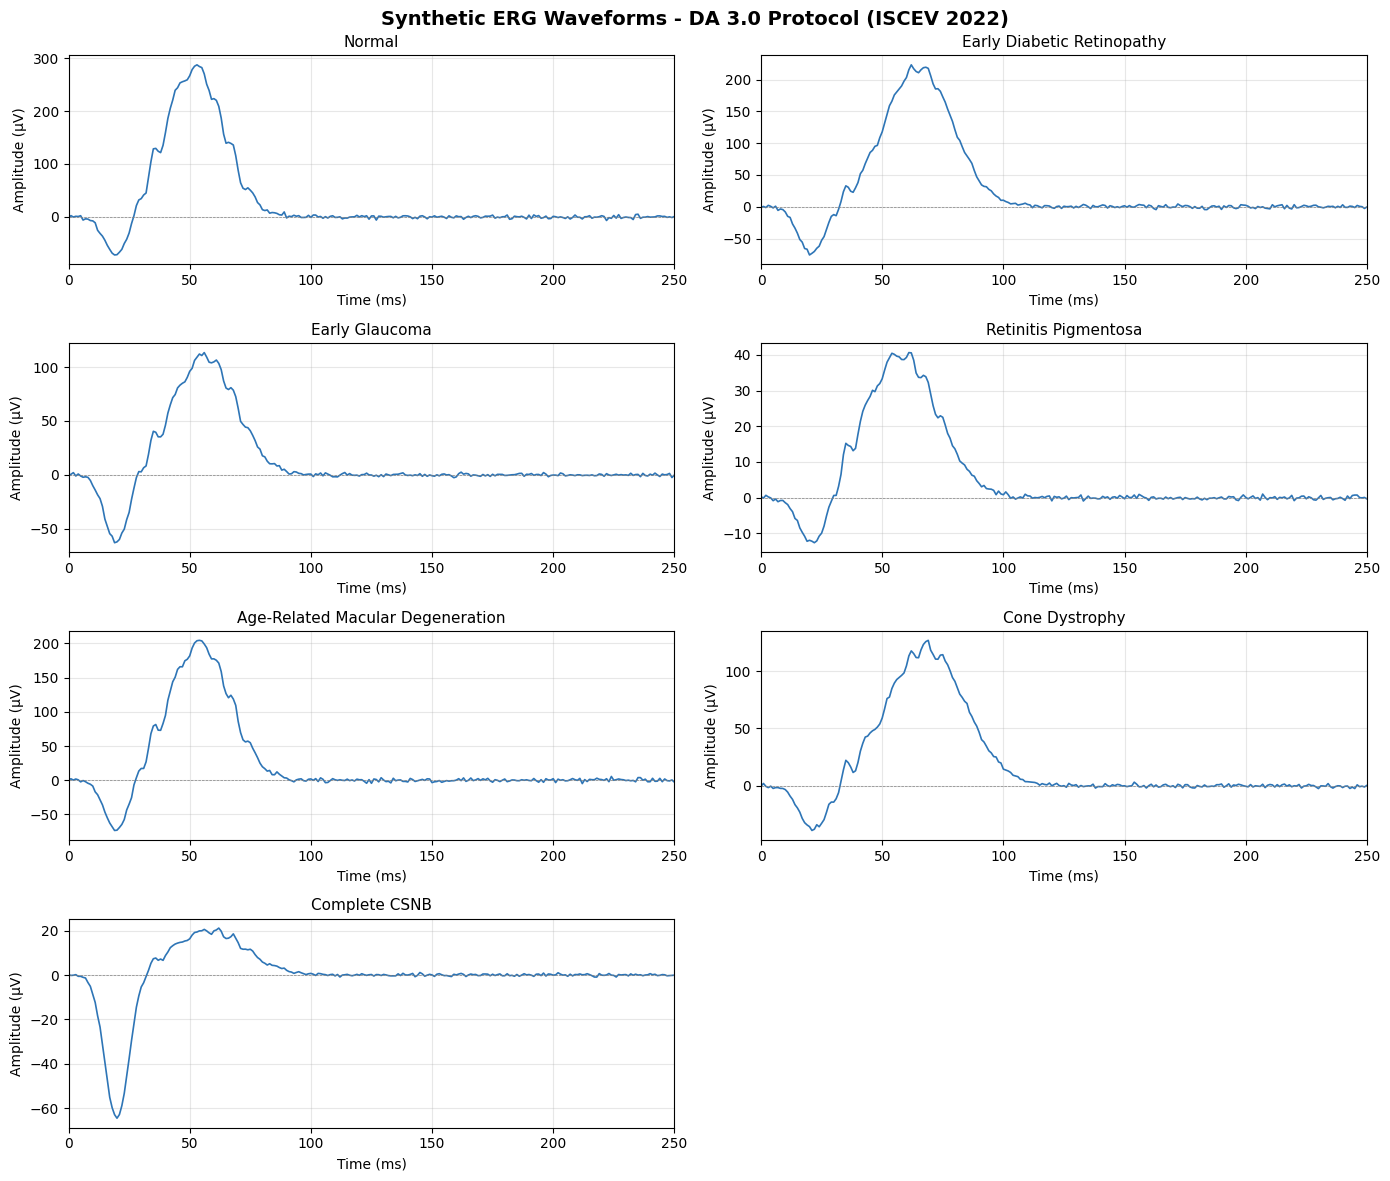


------------------------------------------------------------
SAVING CSV FILES FOR PIPELINE TESTING
------------------------------------------------------------
✓ Saved: synthetic_normal_da3.csv
✓ Saved: synthetic_diabetic_retinopathy_da3.csv
✓ Saved: synthetic_glaucoma_da3.csv
✓ Saved: synthetic_retinitis_pigmentosa_da3.csv
✓ Saved: synthetic_amd_da3.csv
✓ Saved: synthetic_cone_dystrophy_da3.csv
✓ Saved: synthetic_csnb_da3.csv

✓ All 7 synthetic ERG files generated successfully
  Files saved in current directory:
    1. synthetic_normal_da3.csv
    2. synthetic_diabetic_retinopathy_da3.csv
    3. synthetic_glaucoma_da3.csv
    4. synthetic_retinitis_pigmentosa_da3.csv
    5. synthetic_amd_da3.csv
    6. synthetic_cone_dystrophy_da3.csv
    7. synthetic_csnb_da3.csv

📌 Next Steps:
  1. Download these CSV files
  2. Upload to the pipeline UI (Cell 7)
  3. Verify each disease class produces appropriate output


In [50]:
# ============================================================================
# CELL 8: SYNTHETIC ERG GENERATOR FOR 7 DISEASE CLASSES (CORRECTED)
# Generates realistic DA 3.0 ERG waveforms for:
#   1. Normal
#   2. Diabetic Retinopathy (early)
#   3. Glaucoma (early)
#   4. Retinitis Pigmentosa / Rod Dystrophy (rod-cone dystrophy)
#   5. Age-Related Macular Degeneration (AMD)
#   6. Cone Dystrophy
#   7. Complete CSNB
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import pandas as pd
from IPython.display import display, HTML
import base64
import io

class SyntheticERFGenerator:
    """
    Synthetic ERG Generator for 7 Disease Classes
    Based on ISCEV 2022 morphological characteristics
    """

    def __init__(self, fs_hz: int = 1000, duration_ms: int = 300):
        self.fs = fs_hz
        self.duration_ms = duration_ms
        self.t = np.arange(0, duration_ms, 1000/fs_hz)

    def _gaussian(self, t, amplitude, center, width):
        """Gaussian function for waveform components"""
        return amplitude * np.exp(-((t - center) ** 2) / (2 * width ** 2))

    def _add_noise(self, signal, snr_db: float = 30):
        """Add Gaussian noise with specified SNR"""
        noise_power = np.var(signal) / (10 ** (snr_db / 10))
        noise = np.sqrt(noise_power) * np.random.randn(len(signal))
        return signal + noise

    def _add_ops(self, t, base_bwave, op_scale=1.0):
        """Add oscillatory potentials to b-wave"""
        # OPs are high-frequency oscillations on ascending limb of b-wave (30-70 ms)
        op_freqs = [95, 120, 150, 180]  # Hz
        op_amps = [8, 12, 10, 6]  # µV (reduced for disease states)

        op_signal = np.zeros_like(t)
        for freq, amp in zip(op_freqs, op_amps):
            # Modulate by b-wave shape (OPs only where b-wave is rising)
            envelope = np.exp(-((t - 50) ** 2) / (2 * 20 ** 2))
            op_signal += amp * op_scale * np.sin(2 * np.pi * freq * t / 1000) * envelope

        return base_bwave + op_signal

    def generate_normal(self, snr_db: float = 30) -> np.ndarray:
        """
        Normal DA 3.0 ERG
        Characteristics: Robust a-wave (-50 to -100 µV), prominent b-wave (200-400 µV)
        """
        # a-wave: photoreceptor response (negative, peak 15-25 ms)
        a_wave = self._gaussian(self.t, -80, 20, 5)

        # b-wave: bipolar cell response (positive, peak 40-80 ms)
        b_wave = self._gaussian(self.t, 280, 52, 12)

        # Combine
        signal = a_wave + b_wave

        # Add OPs
        signal = self._add_ops(self.t, signal, op_scale=1.0)

        # Add noise
        signal = self._add_noise(signal, snr_db)

        return signal

    def generate_diabetic_retinopathy_early(self, snr_db: float = 30) -> np.ndarray:
        """
        Early Diabetic Retinopathy
        Characteristics: Normal a-wave, delayed b-wave, reduced OPs
        """
        # a-wave: normal or slightly reduced
        a_wave = self._gaussian(self.t, -75, 21, 5.5)

        # b-wave: delayed peak (55-85 ms) and slightly reduced amplitude
        b_wave = self._gaussian(self.t, 220, 65, 14)

        signal = a_wave + b_wave

        # OPs: reduced amplitude (40-60% of normal)
        signal = self._add_ops(self.t, signal, op_scale=0.5)

        signal = self._add_noise(signal, snr_db)

        return signal

    def generate_glaucoma_early(self, snr_db: float = 30) -> np.ndarray:
        """
        Early Glaucoma - Clinically significant reduction
        b-wave amplitude ~100-120 µV (Z ≈ -3.0 to -3.5)
        """
        a_wave = self._gaussian(self.t, -65, 20, 5)
        b_wave = self._gaussian(self.t, 110, 56, 13)  # Reduced to 110 µV
        signal = a_wave + b_wave
        signal = self._add_ops(self.t, signal, op_scale=0.4)
        signal = self._add_noise(signal, snr_db)
        return signal

    def generate_rp_rod_cone_dystrophy(self, snr_db: float = 30) -> np.ndarray:
        """
        Retinitis Pigmentosa / Rod Dystrophy (rod-cone dystrophy)
        Characteristics: Severely reduced or extinguished a-wave and b-wave
        """
        # a-wave: severely reduced (rod photoreceptor loss)
        a_wave = self._gaussian(self.t, -15, 22, 6)

        # b-wave: severely reduced
        b_wave = self._gaussian(self.t, 40, 58, 15)

        signal = a_wave + b_wave

        # OPs: absent or barely visible
        signal = self._add_ops(self.t, signal, op_scale=0.15)

        signal = self._add_noise(signal, snr_db)

        return signal

    def generate_amd(self, snr_db: float = 30) -> np.ndarray:
        """
        Age-Related Macular Degeneration (early)
        Characteristics: Reduced b-wave, normal a-wave, reduced OPs
        """
        # a-wave: normal (photoreceptors intact in early AMD)
        a_wave = self._gaussian(self.t, -78, 20, 5)

        # b-wave: mildly reduced (bipolar cell dysfunction)
        b_wave = self._gaussian(self.t, 200, 54, 12.5)

        signal = a_wave + b_wave

        # OPs: mildly reduced
        signal = self._add_ops(self.t, signal, op_scale=0.7)

        signal = self._add_noise(signal, snr_db)

        return signal

    def generate_cone_dystrophy(self, snr_db: float = 30) -> np.ndarray:
        """
        Cone Dystrophy
        Characteristics: Reduced a-wave (cone contribution), delayed implicit times
        """
        # a-wave: reduced (cone photoreceptor loss)
        a_wave = self._gaussian(self.t, -40, 22, 6)

        # b-wave: reduced and delayed
        b_wave = self._gaussian(self.t, 120, 68, 16)

        signal = a_wave + b_wave

        # OPs: reduced
        signal = self._add_ops(self.t, signal, op_scale=0.4)

        signal = self._add_noise(signal, snr_db)

        return signal

    def generate_csnb_complete(self, snr_db: float = 30) -> np.ndarray:
        """
        Complete CSNB (Congenital Stationary Night Blindness)
        Characteristics: Negative waveform (absent b-wave, preserved a-wave)
        """
        # a-wave: normal or slightly reduced (photoreceptors intact)
        a_wave = self._gaussian(self.t, -65, 20, 5)

        # b-wave: severely reduced (ON-bipolar cell dysfunction)
        b_wave = self._gaussian(self.t, 20, 58, 15)

        signal = a_wave + b_wave

        # OPs: absent (inner retinal dysfunction)
        signal = self._add_ops(self.t, signal, op_scale=0.1)

        signal = self._add_noise(signal, snr_db)

        return signal

    def generate_all_signals(self) -> dict:
        """Generate all 7 disease classes + normal"""
        return {
            'normal': self.generate_normal(),
            'diabetic_retinopathy': self.generate_diabetic_retinopathy_early(),
            'glaucoma': self.generate_glaucoma_early(),
            'retinitis_pigmentosa': self.generate_rp_rod_cone_dystrophy(),
            'amd': self.generate_amd(),
            'cone_dystrophy': self.generate_cone_dystrophy(),
            'csnb': self.generate_csnb_complete()
        }

    def save_to_csv(self, signal: np.ndarray, filename: str):
        """Save signal to CSV in standardized format"""
        df = pd.DataFrame({
            'Time_ms': self.t,
            'Amplitude_uV': signal
        })
        df.to_csv(filename, index=False)
        print(f"✓ Saved: {filename}")

    def plot_comparison(self):
        """Plot all 7 disease classes for visual comparison"""
        signals = self.generate_all_signals()

        fig, axes = plt.subplots(4, 2, figsize=(14, 12))
        axes = axes.flatten()

        disease_names = {
            'normal': 'Normal',
            'diabetic_retinopathy': 'Early Diabetic Retinopathy',
            'glaucoma': 'Early Glaucoma',
            'retinitis_pigmentosa': 'Retinitis Pigmentosa',
            'amd': 'Age-Related Macular Degeneration',
            'cone_dystrophy': 'Cone Dystrophy',
            'csnb': 'Complete CSNB'
        }

        for idx, (key, name) in enumerate(disease_names.items()):
            ax = axes[idx]
            ax.plot(self.t, signals[key], color='#2E75B6', lw=1.2)
            ax.axhline(0, color='gray', ls='--', lw=0.5)
            ax.set_title(f'{name}', fontsize=11)
            ax.set_xlabel('Time (ms)')
            ax.set_ylabel('Amplitude (µV)')
            ax.grid(True, alpha=0.3)
            ax.set_xlim(0, 250)

        axes[7].axis('off')
        plt.suptitle('Synthetic ERG Waveforms - DA 3.0 Protocol (ISCEV 2022)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        return signals


# ============================================================================
# Generate and Save All Synthetic ERG Files
# ============================================================================

print("=" * 60)
print("SYNTHETIC ERG GENERATOR FOR 7 DISEASE CLASSES")
print("ISCEV 2022 Compliant Waveforms")
print("=" * 60)

# Initialize generator (CORRECTED CLASS NAME)
generator = SyntheticERFGenerator(fs_hz=1000, duration_ms=300)

# Generate all signals
signals = generator.generate_all_signals()

# Display waveform comparison
generator.plot_comparison()

# Save all signals to CSV files for testing
print("\n" + "-" * 60)
print("SAVING CSV FILES FOR PIPELINE TESTING")
print("-" * 60)

for disease_name, signal in signals.items():
    filename = f"synthetic_{disease_name}_da3.csv"
    generator.save_to_csv(signal, filename)

print("\n" + "=" * 60)
print("✓ All 7 synthetic ERG files generated successfully")
print("  Files saved in current directory:")
print("    1. synthetic_normal_da3.csv")
print("    2. synthetic_diabetic_retinopathy_da3.csv")
print("    3. synthetic_glaucoma_da3.csv")
print("    4. synthetic_retinitis_pigmentosa_da3.csv")
print("    5. synthetic_amd_da3.csv")
print("    6. synthetic_cone_dystrophy_da3.csv")
print("    7. synthetic_csnb_da3.csv")
print("=" * 60)
print("\n📌 Next Steps:")
print("  1. Download these CSV files")
print("  2. Upload to the pipeline UI (Cell 7)")
print("  3. Verify each disease class produces appropriate output")
print("=" * 60)

In [48]:
# Quick validation of generated files
import pandas as pd
import os

files = [
    'synthetic_normal_da3.csv',
    'synthetic_diabetic_retinopathy_da3.csv',
    'synthetic_glaucoma_da3.csv',
    'synthetic_retinitis_pigmentosa_da3.csv',
    'synthetic_amd_da3.csv',
    'synthetic_cone_dystrophy_da3.csv',
    'synthetic_csnb_da3.csv'
]

print("=" * 60)
print("SYNTHETIC FILES VALIDATION")
print("=" * 60)

for f in files:
    if os.path.exists(f):
        df = pd.read_csv(f)
        print(f"✓ {f}: {len(df)} samples, range [{df['Amplitude_uV'].min():.1f}, {df['Amplitude_uV'].max():.1f}] µV")
    else:
        print(f"✗ {f}: NOT FOUND")
print("=" * 60)

SYNTHETIC FILES VALIDATION
✓ synthetic_normal_da3.csv: 300 samples, range [-76.4, 286.9] µV
✓ synthetic_diabetic_retinopathy_da3.csv: 300 samples, range [-74.7, 225.7] µV
✓ synthetic_glaucoma_da3.csv: 300 samples, range [-66.7, 133.5] µV
✓ synthetic_retinitis_pigmentosa_da3.csv: 300 samples, range [-12.9, 41.1] µV
✓ synthetic_amd_da3.csv: 300 samples, range [-72.6, 205.3] µV
✓ synthetic_cone_dystrophy_da3.csv: 300 samples, range [-38.0, 127.8] µV
✓ synthetic_csnb_da3.csv: 300 samples, range [-64.3, 20.6] µV
